In [1]:
# ==============================
# 📦 IMPORTS
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración opcional para que se vea mejor
pd.set_option("display.max_columns", None)
plt.style.use("default")

In [2]:
# ==============================
# 📂 CARGA DEL DATASET
# ==============================

ruta = "../data/raw/survey.csv"

df = pd.read_csv(ruta)

print("✅ Dataset cargado correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

display(df.head())

✅ Dataset cargado correctamente
Filas: 1259
Columnas: 27


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [3]:
# ==============================
# 🔎 FUNCIÓN EDA BÁSICA
# ==============================

def eda_basico(df):
    
    print("📊 INFORMACIÓN GENERAL")
    print("-" * 50)
    print("Shape:", df.shape)
    print("\nTipos de datos:")
    display(df.dtypes)
    
    
    print("\n" + "="*60)
    print("🔍 VALORES NULOS")
    print("-" * 50)
    nulos = df.isnull().sum()
    porcentaje_nulos = (nulos / len(df)) * 100
    
    tabla_nulos = pd.DataFrame({
        "nulos": nulos,
        "% nulos": porcentaje_nulos
    }).sort_values(by="% nulos", ascending=False)
    
    display(tabla_nulos[tabla_nulos["nulos"] > 0])
    
    
    print("\n" + "="*60)
    print("🔁 DUPLICADOS")
    print("-" * 50)
    duplicados = df.duplicated().sum()
    print("Número de duplicados:", duplicados)
    
    
    print("\n" + "="*60)
    print("📈 VARIABLES NUMÉRICAS")
    print("-" * 50)
    display(df.describe())
    
    
    print("\n" + "="*60)
    print("🗂️ VARIABLES CATEGÓRICAS")
    print("-" * 50)
    
    columnas_categoricas = df.select_dtypes(include="object").columns
    
    for col in columnas_categoricas:
        print(f"\n🔹 {col}")
        print("Valores únicos:", df[col].nunique())
        display(df[col].value_counts().head())

In [4]:
eda_basico(df)

📊 INFORMACIÓN GENERAL
--------------------------------------------------
Shape: (1259, 27)

Tipos de datos:


Timestamp                    object
Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
obs_consequence              object
comments                     object
dtype: object


🔍 VALORES NULOS
--------------------------------------------------


,nulos,% nulos
comments,1095,86.973789
state,515,40.905481
work_interfere,264,20.969023
self_employed,18,1.429706



🔁 DUPLICADOS
--------------------------------------------------
Número de duplicados: 0

📈 VARIABLES NUMÉRICAS
--------------------------------------------------


...

mental_vs_physical
Don't know    576
Yes           343
No            340
Name: count, dtype: int64


🔹 obs_consequence
Valores únicos: 2


obs_consequence
No     1075
Yes     184
Name: count, dtype: int64


🔹 comments
Valores únicos: 160


comments
* Small family business - YMMV.                                                                                                                                                                                                                                          5
I'm not on my company's health insurance which could be part of the reason I answered Don't know to so many questions.                                                                                                                                                   1
My company does provide healthcare but not to me as I'm on a fixed-term contract. The mental healthcare I use is provided entirely outside of my work.                                                                                                                   1
I have chronic low-level neurological issues that have mental health side effects. One of my supervisors has also experienced similar neurological problems so I feel more comfortable being o

In [5]:
# ==============================
# 🧹 FUNCIÓN LIMPIEZA DATASET
# ==============================

def limpiar_dataset(df):

    df = df.copy()

    # eliminar columnas que no aportan al análisis
    df = df.drop(columns=["Timestamp", "comments"], errors="ignore")

    # limpiar edades incorrectas
    df = df[(df["Age"] >= 18) & (df["Age"] <= 65)]

    # normalizar gender
    df["Gender"] = df["Gender"].str.lower()

    gender_map = {
        "male": "Male",
        "m": "Male",
        "male-ish": "Male",
        "maile": "Male",
        "mal": "Male",
        "msle": "Male",

        "female": "Female",
        "f": "Female",
        "woman": "Female",
        "female ": "Female"
    }

    df["Gender"] = df["Gender"].replace(gender_map)

    # todo lo demás como Other
    df["Gender"] = df["Gender"].apply(
        lambda x: x if x in ["Male", "Female"] else "Other"
    )

    # agrupar países menos frecuentes
    top_countries = ["United States", "United Kingdom", "Canada", "Germany", "Netherlands"]

    df["Country"] = df["Country"].apply(
        lambda x: x if x in top_countries else "Other"
    )

    # eliminar state (solo aplica a USA)
    df = df.drop(columns=["state"], errors="ignore")

    print("✅ Limpieza completada")
    print("Filas:", df.shape[0])
    print("Columnas:", df.shape[1])

    return df

In [6]:
df_clean = limpiar_dataset(df)

✅ Limpieza completada
Filas: 1250
Columnas: 24


In [7]:
# ==============================
# 🔢 FUNCIÓN MAPEO BINARIO
# ==============================

def mapear_binarias(df):

    df_corr = df.copy()

    yes_no_map = {
        "Yes": 1,
        "No": 0
    }

    columnas_binarias = [
        "self_employed",
        "family_history",
        "treatment",
        "remote_work",
        "tech_company",
        "obs_consequence"
    ]

    for col in columnas_binarias:
        df_corr[col] = df_corr[col].map(yes_no_map)

    print("✅ Variables binarias mapeadas")

    return df_corr

In [8]:
df_corr = mapear_binarias(df_clean)

✅ Variables binarias mapeadas


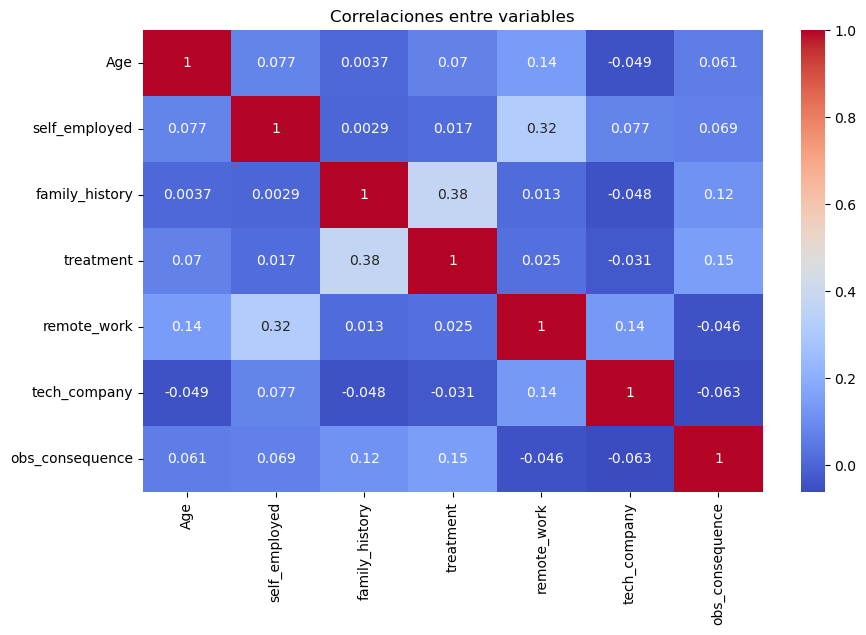

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_corr.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlaciones entre variables")
plt.show()

In [10]:
# ==============================
# 🔢 ENCODE CATEGÓRICAS PEQUEÑAS
# ==============================

def encode_categoricas(df, max_categorias=6):

    df_encoded = df.copy()

    cols_cat = df_encoded.select_dtypes(include="object").columns

    for col in cols_cat:

        n_unique = df_encoded[col].nunique()

        if n_unique <= max_categorias:

            print(f"\n🔹 {col} ({n_unique} categorías)")

            mapping = {v: i for i, v in enumerate(df_encoded[col].dropna().unique())}

            print("Mapping:", mapping)

            df_encoded[col] = df_encoded[col].map(mapping)

    print("\n✅ Codificación completada")

    return df_encoded

In [11]:
df_corr = encode_categoricas(df_clean)


🔹 Gender (3 categorías)
Mapping: {'Female': 0, 'Male': 1, 'Other': 2}

🔹 Country (6 categorías)
Mapping: {'United States': 0, 'Canada': 1, 'United Kingdom': 2, 'Other': 3, 'Netherlands': 4, 'Germany': 5}

🔹 self_employed (2 categorías)
Mapping: {'Yes': 0, 'No': 1}

🔹 family_history (2 categorías)
Mapping: {'No': 0, 'Yes': 1}

🔹 treatment (2 categorías)
Mapping: {'Yes': 0, 'No': 1}

🔹 work_interfere (4 categorías)
Mapping: {'Often': 0, 'Rarely': 1, 'Never': 2, 'Sometimes': 3}

🔹 no_employees (6 categorías)
Mapping: {'6-25': 0, 'More than 1000': 1, '26-100': 2, '100-500': 3, '1-5': 4, '500-1000': 5}

🔹 remote_work (2 categorías)
Mapping: {'No': 0, 'Yes': 1}

🔹 tech_company (2 categorías)
Mapping: {'Yes': 0, 'No': 1}

🔹 benefits (3 categorías)
Mapping: {'Yes': 0, "Don't know": 1, 'No': 2}

🔹 care_options (3 categorías)
Mapping: {'Not sure': 0, 'No': 1, 'Yes': 2}

🔹 wellness_program (3 categorías)
Mapping: {'No': 0, "Don't know": 1, 'Yes': 2}

🔹 seek_help (3 categorías)
Mapping: {'Yes': 0

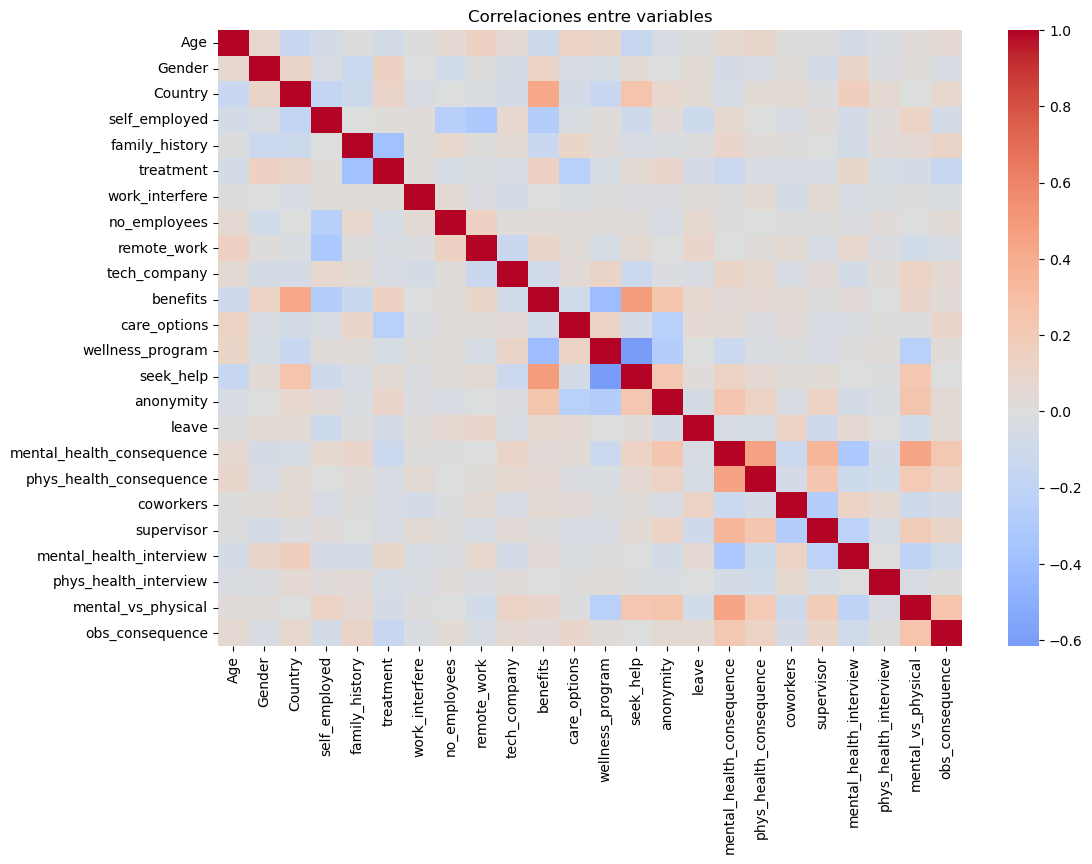

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_corr.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Correlaciones entre variables")
plt.show()

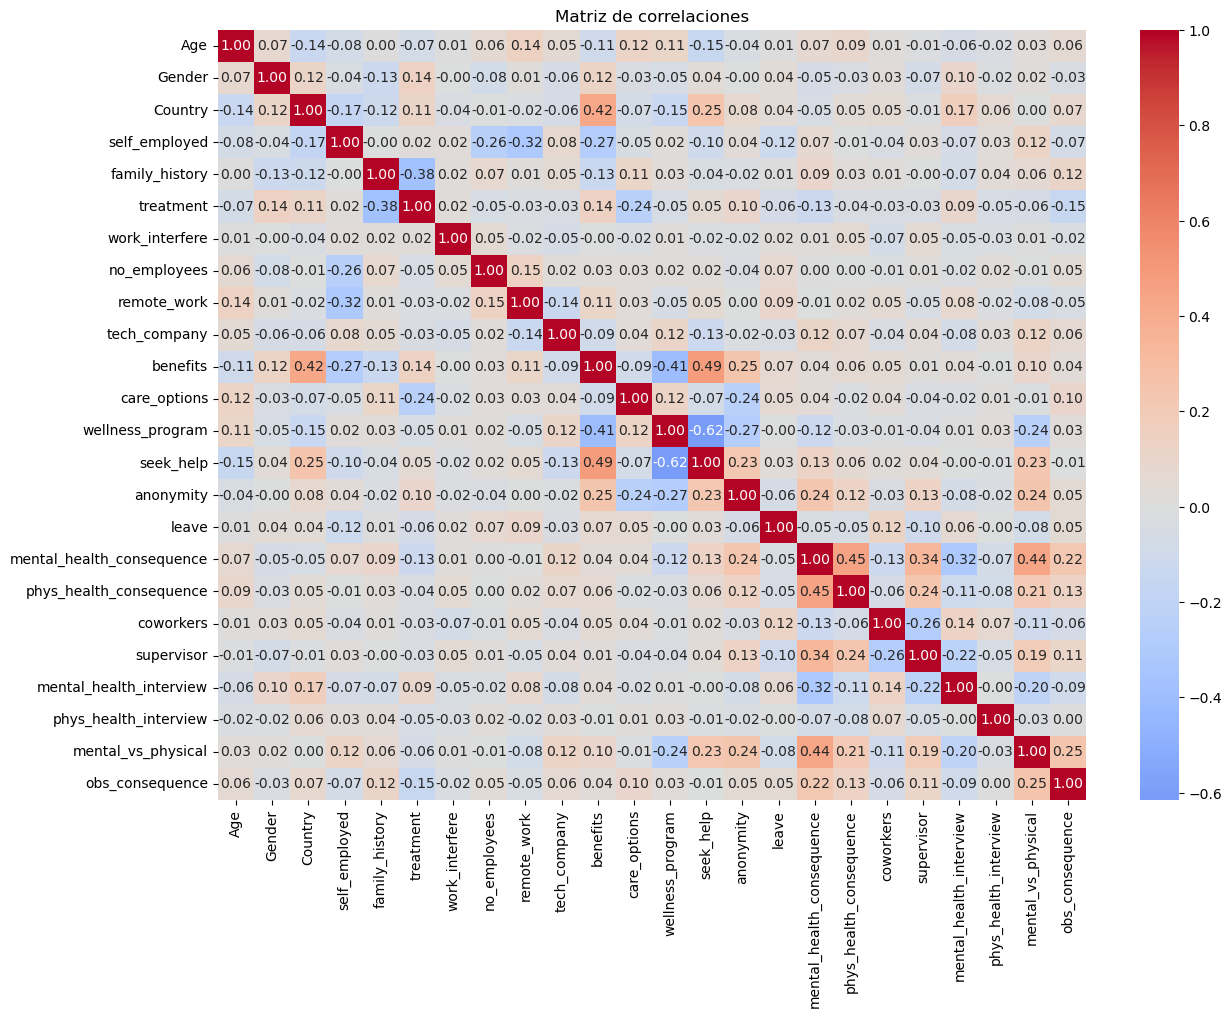

In [13]:
# ==============================
# HEATMAP CON COEFICIENTES
# ==============================

corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlaciones")
plt.show()

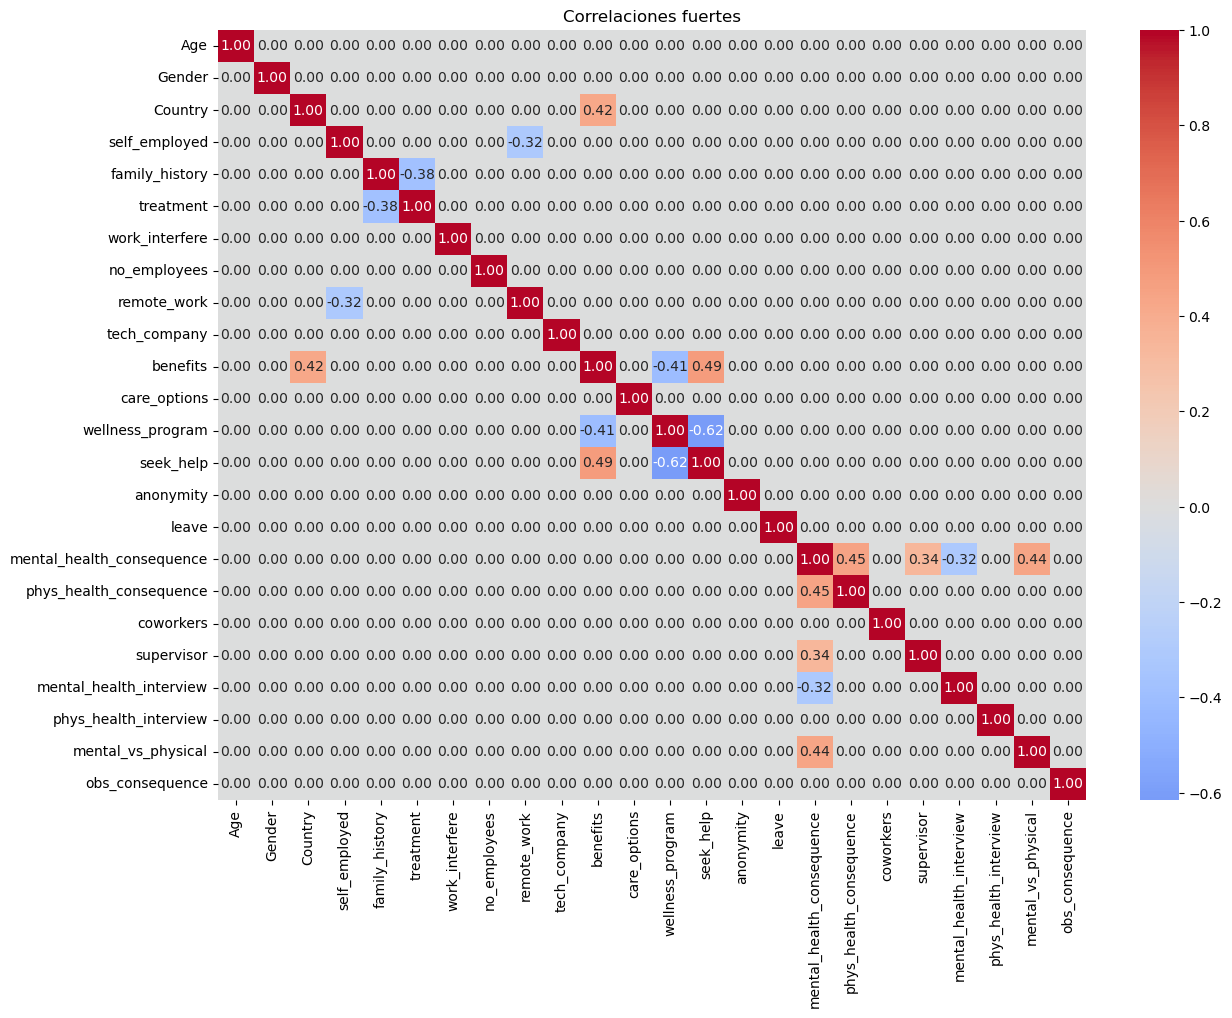

In [14]:
# ==============================
# HEATMAP SOLO CORRELACIONES FUERTES
# ==============================

corr = df_corr.corr(numeric_only=True)

corr_filtrado = corr.copy()

corr_filtrado[(corr_filtrado < 0.3) & (corr_filtrado > -0.3)] = 0

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_filtrado,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlaciones fuertes")
plt.show()

In [16]:
# ==============================
# 🧩 DATASET PARA CLUSTERING (ONE-HOT)
# ==============================

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ✅ df_clean debe ser tu dataframe limpio con categóricas (no el numérico del heatmap)
# Si no lo tienes, créalo: df_clean = limpiar_dataset(df)

# Variables recomendadas (puedes ajustar)
cols_cluster = [
    "family_history",
    "treatment",
    "work_interfere",
    "remote_work",
    "benefits",
    "care_options",
    "wellness_program",
    "seek_help",
    "anonymity",
    "leave",
    "mental_health_consequence",
    "phys_health_consequence",
    "coworkers",
    "supervisor",
    "mental_vs_physical",
    "obs_consequence",
    "Age"
]

df_cluster = df_clean[cols_cluster].copy()

In [17]:
# ==============================
# ⚙️ PIPELINE: ONE-HOT + KMEANS
# ==============================

cat_cols = df_cluster.select_dtypes(include="object").columns.tolist()
num_cols = df_cluster.select_dtypes(exclude="object").columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

# probaremos varios k (número de clusters)
X = preprocess.fit_transform(df_cluster)

c:\Users\Usuario\anaconda3\envs\bootcamp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\Usuario\anaconda3\envs\bootcamp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\Usuario\anaconda3\envs\bootcamp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
c:\Users\Usuario\anaconda3\envs\bootcamp\Lib\site-packages\sklearn\cluster\_kmeans.py:14

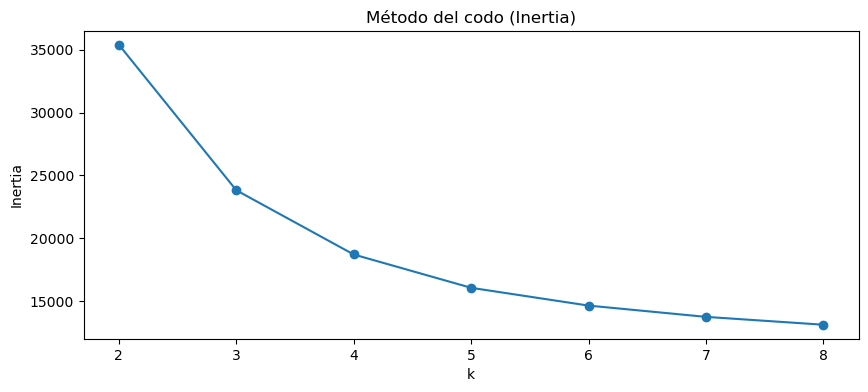

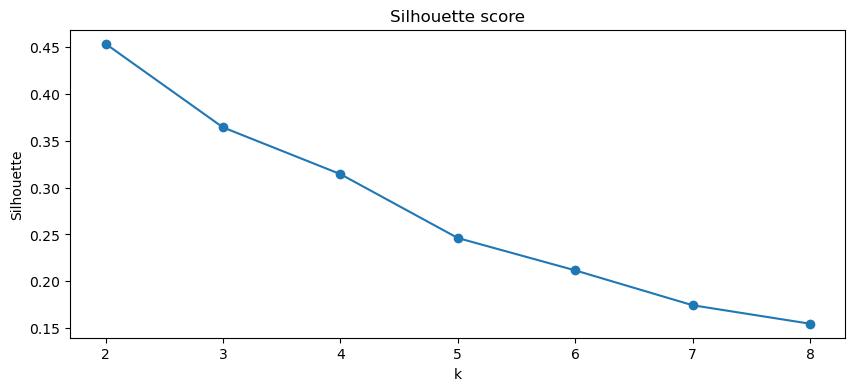

Silhouette por k:
k=2: 0.454
k=3: 0.364
k=4: 0.314
k=5: 0.246
k=6: 0.212
k=7: 0.174
k=8: 0.155


In [18]:
# ==============================
# 🔎 ELEGIR k: CODO + SILHOUETTE
# ==============================

inertias = []
silhouettes = []
k_values = range(2, 9)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X, labels))

plt.figure(figsize=(10,4))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Método del codo (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(list(k_values), silhouettes, marker="o")
plt.title("Silhouette score")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

print("Silhouette por k:")
for k, s in zip(k_values, silhouettes):
    print(f"k={k}: {s:.3f}")

In [19]:
# ==============================
# ✅ MODELO FINAL + CLUSTERS
# ==============================

k_final = 3

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

df_clusters_out = df_cluster.copy()
df_clusters_out["cluster"] = labels

print("✅ Clusters creados")
display(df_clusters_out["cluster"].value_counts())

✅ Clusters creados


c:\Users\Usuario\anaconda3\envs\bootcamp\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


cluster
2    579
1    524
0    147
Name: count, dtype: int64

In [20]:
# ==============================
# 📊 Treatment por cluster
# ==============================

tabla_treatment = pd.crosstab(df_clusters_out["cluster"], df_clusters_out["treatment"], normalize="index")
display(tabla_treatment)

treatment,No,Yes
cluster,,
0,0.414966,0.585034
1,0.482824,0.517176
2,0.526770,0.473230


In [21]:
# ==============================
# 📊 Work interfere por cluster
# ==============================

tabla_interfere = pd.crosstab(df_clusters_out["cluster"], df_clusters_out["work_interfere"], normalize="index")
display(tabla_interfere)

work_interfere,Never,Often,Rarely,Sometimes
cluster,,,,
0,0.235772,0.138211,0.195122,0.430894
1,0.209026,0.125891,0.171021,0.494062
2,0.211712,0.157658,0.173423,0.457207


In [22]:
# ==============================
# 📊 Benefits / Wellness / Seek help por cluster
# ==============================

for col in ["benefits", "wellness_program", "seek_help", "anonymity", "leave"]:
    print(f"\n--- {col} ---")
    display(pd.crosstab(df_clusters_out["cluster"], df_clusters_out[col], normalize="index"))


--- benefits ---


benefits,Don't know,No,Yes
cluster,,,
0,0.292517,0.204082,0.503401
1,0.278626,0.314885,0.406489
2,0.376511,0.303972,0.319516



--- wellness_program ---


wellness_program,Don't know,No,Yes
cluster,,,
0,0.142857,0.605442,0.251701
1,0.137405,0.660305,0.202290
2,0.160622,0.694301,0.145078



--- seek_help ---


seek_help,Don't know,No,Yes
cluster,,,
0,0.285714,0.367347,0.346939
1,0.270992,0.517176,0.211832
2,0.309154,0.545769,0.145078



--- anonymity ---


anonymity,Don't know,No,Yes
cluster,,,
0,0.693878,0.040816,0.265306
1,0.618321,0.047710,0.333969
2,0.670121,0.056995,0.272884



--- leave ---


leave,Don't know,Somewhat difficult,Somewhat easy,Very difficult,Very easy
cluster,,,,,
0,0.517007,0.108844,0.142857,0.102041,0.129252
1,0.419847,0.097328,0.230916,0.085878,0.166031
2,0.457686,0.100173,0.210708,0.063903,0.167530


In [23]:
eda_basico(df_clean)

📊 INFORMACIÓN GENERAL
--------------------------------------------------
Shape: (1250, 24)

Tipos de datos:


Age                           int64
Gender                       object
Country                      object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
obs_consequence              object
dtype: object


🔍 VALORES NULOS
--------------------------------------------------


,nulos,% nulos
work_interfere,262,20.96
self_employed,18,1.44



🔁 DUPLICADOS
--------------------------------------------------
Número de duplicados: 4

📈 VARIABLES NUMÉRICAS
--------------------------------------------------


...

phys_health_interview
Maybe    555
No       495
Yes      200
Name: count, dtype: int64


🔹 mental_vs_physical
Valores únicos: 3


mental_vs_physical
Don't know    573
Yes           339
No            338
Name: count, dtype: int64


🔹 obs_consequence
Valores únicos: 2


obs_consequence
No     1070
Yes     180
Name: count, dtype: int64

In [24]:
# ==============================
# 🧹 LIMPIEZA FINAL ANTES DE EXPORTAR
# ==============================

def limpieza_final_osmi(df):
    df = df.copy()

    # 1) Eliminar duplicados
    duplicados_antes = df.duplicated().sum()
    df = df.drop_duplicates()
    duplicados_despues = df.duplicated().sum()

    # 2) Imputar self_employed con la moda
    if "self_employed" in df.columns:
        moda_self = df["self_employed"].mode(dropna=True)[0]
        df["self_employed"] = df["self_employed"].fillna(moda_self)

    # 3) Imputar work_interfere con nueva categoría
    # (en inglés: "No response" / "Not disclosed")
    if "work_interfere" in df.columns:
        df["work_interfere"] = df["work_interfere"].fillna("No response")

    # 4) Resumen rápido
    print("✅ Limpieza final completada")
    print(f"Duplicados antes: {duplicados_antes} | después: {duplicados_despues}")
    print("\nNulos restantes (solo >0):")
    nulos_restantes = df.isnull().sum()
    display(nulos_restantes[nulos_restantes > 0])

    return df

In [25]:
df_final = limpieza_final_osmi(df_clean)

✅ Limpieza final completada
Duplicados antes: 4 | después: 0

Nulos restantes (solo >0):


Series([], dtype: int64)

In [26]:
# ==============================
# 📤 EXPORTAR CSV LIMPIO PARA POWER BI
# ==============================

ruta_salida = "../data/processed/osmi_mental_health_clean.csv"

df_final.to_csv(ruta_salida, index=False)

print("✅ Exportado correctamente")
print("Ruta:", ruta_salida)

✅ Exportado correctamente
Ruta: ../data/processed/osmi_mental_health_clean.csv


In [28]:
df_final.head()

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,United States,No,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,Male,United States,No,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,No,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,United Kingdom,No,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,United States,No,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No
